# Milestone 3 Notebook — MiDaS Project

**Canvas Project Number:** #77  
**Group Members:** Emily Chen, Cindy Ren, Alice Wang  
**Course / Milestone:** Milestone 3

This notebook is organized to match the milestone requirements:
1. Problem statement refinement and introduction  
2. Comprehensive EDA review  
3. Baseline model selection and justification  
4. Results interpretation and analysis  
5. Final model pipeline setup

## 0. Brief recap of Milestone 2 progress

**Draft recap**

In Milestone 2, we established the foundation for our project by defining a clear problem setting and conducting exploratory analysis on the MiDaS-60 dataset. Our goal is to compare the performance and representation learning of Vision Transformers (ViTs) and Convolutional Neural Networks (CNNs) in a structured, non-natural image domain (Minecraft).

We first introduced the dataset and verified its structure, confirming a balanced class distribution (60 classes with equal samples) and a predefined *train/test* split. Through visual inspection and metadata analysis, we observed that while block classes are defined by consistent local texture and geometry, the dataset contains substantial variability in global context, including biome type and lighting conditions (day vs. night). Importantly, these contextual factors are unevenly distributed and often correlated with specific classes, suggesting a risk that models may rely on spurious background cues rather than intrinsic object features.

Our exploratory data analysis (EDA) further examined pixel-level statistics and metadata distributions. These analyses highlighted that global brightness and environmental context vary significantly across samples, while intra-class visual patterns remain stable. Based on these findings, we concluded that block classification, rather than biome classification—is a more appropriate task for evaluating model architectures, as it requires robustness to contextual variation and emphasizes fine-grained visual features.

Guided by these insights, we designed a preprocessing pipeline that includes normalization (to reduce lighting variation) and carefully controlled data augmentation (e.g., slight cropping, flipping, and mild color jitter). These transformations aim to improve model robustness without distorting the structured patterns inherent in Minecraft blocks.

Overall, Milestone 2 clarified the challenges posed by the dataset and informed our modeling strategy. In particular, it highlighted the importance of disentangling local texture features from global contextual signals, which motivates our comparison between CNNs (local feature bias) and ViTs (global attention mechanisms) in subsequent modeling steps.

## 1. Problem statement refinement and introduction

### Project introduction

This project focuses on image-based classification using the MiDaS-60 dataset, which consists of Minecraft images labeled by block type. Our objective is to evaluate how well computer vision models can distinguish between visually similar categories in a structured, non-natural image domain. In particular, we aim to understand how different modeling choices interact with the dataset’s visual characteristics, including texture consistency and contextual variability.

### Refined research question

**Primary question:** Can a Vision Transformer outperform a Convolutional Neural Network for Minecraft block classification, and do interpretability methods (Attention Rollout vs. Grad-CAM) reveal meaningful differences in the visual representations learned by the two architectures in a non-natural image domain?

### Why this question matters

A well-defined problem is critical because the dataset contains significant contextual variation, such as biome differences and lighting conditions, that are not directly tied to the target labels. Our EDA shows that block-level labels correspond more closely to stable local visual patterns (e.g., texture and structure), whereas higher-level labels (such as biome) are less consistently reflected in the image content. Framing the problem at the block level reduces reliance on spurious background cues, improves interpretability, and leads to more meaningful evaluation of model performance and generalization


In [32]:
# ==== Setup ====
import os
import random
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2A. Colab + GitHub setup

Run the cells below in **Google Colab** after you upload this notebook or open it from GitHub.  
They are written so you can clone your repo, switch to **your own branch**, and push `ms3.ipynb`.

> Replace the placeholders for:
> - `YOUR_REPO_URL`
> - `YOUR_BRANCH_NAME`
> - optional Git identity

In [2]:
# ==== mount Drive  ====
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Data description

**Dataset:** MiDaS-60  
**Source:** `https://github.com/MinecraftDataset/MiDaS/tree/main.`

### Summary
- The dataset contains labeled images organized into training and test folders.
- Each class corresponds to a visual category in the environment.
- Our current framing emphasizes **block classification**.
- The images appear to vary in texture, color, viewpoint, and scene complexity.

### Why this dataset is useful
This dataset allows us to test whether image features are sufficient for distinguishing meaningful environmental categories and whether label granularity affects modeling success.

### Notes / caveats
- Some classes may be visually similar.
- Class imbalance may affect training and evaluation.
- A biome-level formulation may introduce label noise if multiple visually distinct blocks are merged together.

In [3]:
DATA_ROOT = '/content/drive/MyDrive/APcomp209/MiDaS'
SMALL_DIR = os.path.join(DATA_ROOT, 'MiDaS-60_small')
LARGE_DIR = os.path.join(DATA_ROOT, 'MiDaS-60_large')

DATA_DIR = SMALL_DIR

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

print("Train dir exists:", os.path.exists(TRAIN_DIR), TRAIN_DIR)
print("Test dir exists:", os.path.exists(TEST_DIR), TEST_DIR)

Train dir exists: True /content/drive/MyDrive/MiDaS/MiDaS-60_small/train
Test dir exists: True /content/drive/MyDrive/MiDaS/MiDaS-60_small/test


In [4]:
# ==== Load raw dataset for EDA only ====
eda_transform = transforms.ToTensor()

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=eda_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eda_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Raw train size:", len(train_dataset))
print("Raw test size:", len(test_dataset))
print("Number of classes:", num_classes)
print("EDA dataset loaded without resize/normalization.")

Raw train size: 32400
Raw test size: 3600
Number of classes: 60
EDA dataset loaded without resize/normalization.


In [5]:
# ==== Basic dataset table ====
train_counts = Counter([label for _, label in train_dataset.samples])
test_counts = Counter([label for _, label in test_dataset.samples])

class_df = pd.DataFrame({
    "class_name": train_dataset.classes,
    "train_count": [train_counts.get(i, 0) for i in range(len(train_dataset.classes))],
    "test_count":  [test_counts.get(i, 0) for i in range(len(train_dataset.classes))],
})
class_df["total_count"] = class_df["train_count"] + class_df["test_count"]
class_df = class_df.sort_values("total_count", ascending=False).reset_index(drop=True)

display(class_df.head(20))
print("Total images:", class_df["total_count"].sum())

,class_name,train_count,test_count,total_count
0,acacia_log,540,60,600
1,acacia_planks,540,60,600
2,bed,540,60,600
3,birch_log,540,60,600
4,birch_planks,540,60,600
5,bookshelf,540,60,600
6,bricks,540,60,600
7,chest,540,60,600
8,clay,540,60,600
9,coal_ore,540,60,600


Total images: 36000


## 4. Comprehensive EDA review

In this section, summarize the most important EDA findings and explain how they influenced preprocessing and model choice.

### Points to discuss
- Which classes are most represented / underrepresented?
- Are some classes visually similar to each other?
- Does block-level classification appear more reasonable than biome-level classification?
- Do image dimensions or quality vary?
- What preprocessing decisions were motivated by these observations?

## 5. Feature engineering and preprocessing

### Current preprocessing decisions


### Why these choices make sense


## 6. Baseline model selection and justification

### Baseline choice
A simple but relevant baseline for image classification is a small CNN or a transfer-learning model such as ResNet18. This type of model is more appropriate than linear or logistic regression alone because the task depends heavily on spatial image structure.

### Justification
- **Simple enough** to train and explain
- **Relevant** for image data
- **Interpretable enough** at the level of confusion matrices and class-wise performance
- Serves as a practical benchmark before trying more advanced architectures

#### Load transformed dataset for baseline training

In [6]:
# ==== Load transformed dataset saved on Drive for better efficiency====
# See the code at the end for producing this transformed dataset

TRANSFORMED_ROOT_DRIVE = "/content/drive/MyDrive/APcomp209/MiDaS_224"
TRANSFORMED_DATASET_NAME = "MiDaS-60_small"

TRANSFORMED_ROOT_LOCAL = "/content/MiDaS_224"
TRANSFORMED_LOCAL_DIR = os.path.join(TRANSFORMED_ROOT_LOCAL, TRANSFORMED_DATASET_NAME)
TRANSFORMED_DRIVE_DIR = os.path.join(TRANSFORMED_ROOT_DRIVE, TRANSFORMED_DATASET_NAME)

if not os.path.exists(TRANSFORMED_DRIVE_DIR):
    raise FileNotFoundError(
        f"Transformed dataset not found on Drive: {TRANSFORMED_DRIVE_DIR}"
    )

os.makedirs(TRANSFORMED_ROOT_LOCAL, exist_ok=True)

if not os.path.exists(TRANSFORMED_LOCAL_DIR):
    print("Copying transformed dataset from Drive to local Colab storage...")
    !cp -r "$TRANSFORMED_DRIVE_DIR" "$TRANSFORMED_ROOT_LOCAL"
else:
    print("Local transformed dataset already exists.")

BASELINE_TRAIN_DIR = os.path.join(TRANSFORMED_LOCAL_DIR, "train")
BASELINE_TEST_DIR = os.path.join(TRANSFORMED_LOCAL_DIR, "test")

print("Baseline train dir exists:", os.path.exists(BASELINE_TRAIN_DIR), BASELINE_TRAIN_DIR)
print("Baseline test dir exists:", os.path.exists(BASELINE_TEST_DIR), BASELINE_TEST_DIR)

Copying transformed dataset from Drive to local Colab storage...
Baseline train dir exists: True /content/MiDaS_224/MiDaS-60_small/train
Baseline test dir exists: True /content/MiDaS_224/MiDaS-60_small/test


In [22]:
# ==== Build fast dataloaders from transformed dataset ====

baseline_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

baseline_eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_train_dataset = datasets.ImageFolder(BASELINE_TRAIN_DIR, transform=baseline_train_transform)
test_dataset = datasets.ImageFolder(BASELINE_TEST_DIR, transform=baseline_eval_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Full train size:", len(full_train_dataset))
print("Test size:", len(test_dataset))
print("Number of classes:", num_classes)

Full train size: 32400
Test size: 3600
Number of classes: 60


In [23]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train split size:", len(train_dataset))
print("Validation split size:", len(val_dataset))

# reset validation transform to evaluation transform
val_dataset.dataset.transform = baseline_eval_transform

Train split size: 25920
Validation split size: 6480


In [28]:
# Dataloaders
baseline_train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

baseline_val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

baseline_test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

#### Build ResNet-18 model

In [10]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# replace final fully connected layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Fine-tuning setup

We use **partial fine-tuning**: freeze early layers and train only `layer4` and the final `fc` layer. This keeps training efficient while still allowing the model to adapt high-level visual features to the MiDaS dataset.


In [11]:
# freeze earlier layers
for param in model.parameters():
    param.requires_grad = False

# unfreeze layer4 and fc
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# show how many parameters are trainable
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,}")

Trainable params: 8,424,508 / 11,207,292


In [12]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [15]:
# Training and evaluation functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds

In [29]:
num_epochs = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

CHECKPOINT_DIR = "/content/drive/MyDrive/APcomp209/ms3_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_resnet18_ms3_val10_checkpoint.pth")

if os.path.exists(BEST_MODEL_PATH):
    print(f"Found existing checkpoint at: {BEST_MODEL_PATH}")

    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    trained_epochs = checkpoint["trained_epochs"]

    print(f"Loaded saved best model from {trained_epochs} epoch(s).")
    print(f"Best saved validation accuracy: {best_val_acc:.4f}")

else:
    print("No saved checkpoint found. Start training...")

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, baseline_train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, baseline_val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

            checkpoint = {
                "model_state_dict": best_model_wts,
                "history": history,
                "best_val_acc": best_val_acc,
                "trained_epochs": epoch + 1
            }
            torch.save(checkpoint, BEST_MODEL_PATH)

        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Time: {elapsed:.1f}s")

    model.load_state_dict(best_model_wts)
    print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")


No saved checkpoint found. Start training...
Epoch [1/10] Train Loss: 0.0087 | Train Acc: 0.9975 | Val Loss: 0.0069 | Val Acc: 0.9986 | Time: 28.1s
Epoch [2/10] Train Loss: 0.0040 | Train Acc: 0.9991 | Val Loss: 0.0017 | Val Acc: 0.9997 | Time: 26.6s
Epoch [3/10] Train Loss: 0.0009 | Train Acc: 0.9999 | Val Loss: 0.0024 | Val Acc: 0.9992 | Time: 26.4s
Epoch [4/10] Train Loss: 0.0026 | Train Acc: 0.9991 | Val Loss: 0.0036 | Val Acc: 0.9986 | Time: 26.5s
Epoch [5/10] Train Loss: 0.0022 | Train Acc: 0.9994 | Val Loss: 0.0024 | Val Acc: 0.9995 | Time: 26.3s
Epoch [6/10] Train Loss: 0.0048 | Train Acc: 0.9990 | Val Loss: 0.0032 | Val Acc: 0.9992 | Time: 26.6s
Epoch [7/10] Train Loss: 0.0040 | Train Acc: 0.9990 | Val Loss: 0.0024 | Val Acc: 0.9992 | Time: 26.5s
Epoch [8/10] Train Loss: 0.0015 | Train Acc: 0.9998 | Val Loss: 0.0081 | Val Acc: 0.9975 | Time: 26.5s
Epoch [9/10] Train Loss: 0.0025 | Train Acc: 0.9992 | Val Loss: 0.0075 | Val Acc: 0.9972 | Time: 26.3s
Epoch [10/10] Train Loss: 0.

## 7. Results interpretation and analysis


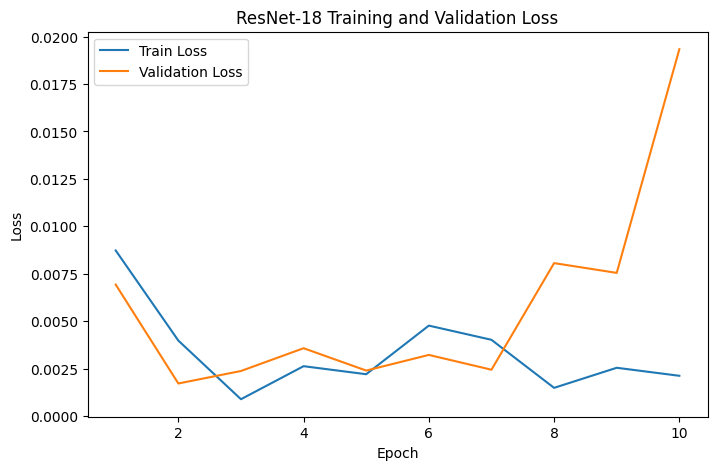

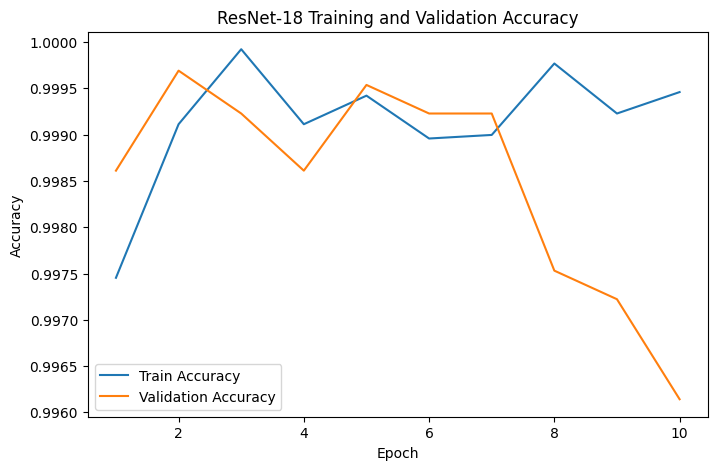

In [30]:
if len(history["train_loss"]) > 0:
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ResNet-18 Training and Validation Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("ResNet-18 Training and Validation Accuracy")
    plt.legend()
    plt.show()
else:
    print("No training history available.")

In [31]:
# Final evaluation on the test set
test_loss, test_acc, y_true, y_pred = evaluate(model, baseline_test_loader, criterion, device)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.0375
Final Test Accuracy: 0.9889


## 8. Future directions

## 9. Final model pipeline setup


## Archived code for creating transformed dataset for better computing efficiency

In [ ]:
"""
# ===== User-editable paths =====
# Raw dataset in Google Drive
DRIVE_RAW_ROOT = "/content/drive/MyDrive/MiDaS"
RAW_DATASET_NAME = "MiDaS-60_small"   # change to "MiDaS-60_large" if needed

# Preprocessed dataset folders
RESIZED_TAG = "224"                   # used in output folder name
LOCAL_WORK_ROOT = "/content"
LOCAL_RAW_ROOT = os.path.join(LOCAL_WORK_ROOT, "MiDaS_raw")
LOCAL_RESIZED_ROOT = os.path.join(LOCAL_WORK_ROOT, f"MiDaS_{RESIZED_TAG}")
DRIVE_RESIZED_ROOT = f"/content/drive/MyDrive/MiDaS_{RESIZED_TAG}"

# Derived paths
RAW_SRC_DIR = os.path.join(DRIVE_RAW_ROOT, RAW_DATASET_NAME)
LOCAL_RAW_DIR = os.path.join(LOCAL_RAW_ROOT, RAW_DATASET_NAME)
LOCAL_RESIZED_DIR = os.path.join(LOCAL_RESIZED_ROOT, RAW_DATASET_NAME)
DRIVE_RESIZED_DIR = os.path.join(DRIVE_RESIZED_ROOT, RAW_DATASET_NAME)

IMG_SIZE = (224, 224)

print("RAW_SRC_DIR:", RAW_SRC_DIR)
print("LOCAL_RAW_DIR:", LOCAL_RAW_DIR)
print("LOCAL_RESIZED_DIR:", LOCAL_RESIZED_DIR)
print("DRIVE_RESIZED_DIR:", DRIVE_RESIZED_DIR)
"""

In [ ]:
"""
# Copy raw dataset from Drive to local Colab storage
os.makedirs(LOCAL_RAW_ROOT, exist_ok=True)

if not os.path.exists(LOCAL_RAW_DIR):
    print("Copying raw dataset from Drive to local storage...")
    !cp -rL "$RAW_SRC_DIR" "$LOCAL_RAW_ROOT"
else:
    print("Local raw dataset already exists.")

print("Exists locally:", os.path.exists(LOCAL_RAW_DIR))
"""

In [ ]:
"""
#Preprocess once: resize all images and save a new dataset
def preprocess_and_save_imagefolder(src_root, dst_root, img_size=(224, 224), save_format="PNG"):
    os.makedirs(dst_root, exist_ok=True)

    for split in ["train", "test"]:
        src_split = os.path.join(src_root, split)
        dst_split = os.path.join(dst_root, split)
        os.makedirs(dst_split, exist_ok=True)

        classes = sorted([d for d in os.listdir(src_split) if os.path.isdir(os.path.join(src_split, d))])

        for cls in tqdm(classes, desc=f"Processing {split}"):
            src_cls = os.path.join(src_split, cls)
            dst_cls = os.path.join(dst_split, cls)
            os.makedirs(dst_cls, exist_ok=True)

            for fname in os.listdir(src_cls):
                src_path = os.path.join(src_cls, fname)

                stem = Path(fname).stem
                ext = ".png" if save_format.upper() == "PNG" else ".jpg"
                dst_path = os.path.join(dst_cls, stem + ext)

                if os.path.exists(dst_path):
                    continue

                try:
                    with Image.open(src_path) as img:
                        img = img.convert("RGB")
                        img = img.resize(img_size, Image.BILINEAR)
                        if save_format.upper() == "PNG":
                            img.save(dst_path, format="PNG")
                        else:
                            img.save(dst_path, format="JPEG", quality=95)
                except Exception as e:
                    print(f"Skipping {src_path}: {e}")
"""

In [ ]:
"""
if not os.path.exists(os.path.join(LOCAL_RESIZED_DIR, "train")):
    print("Creating resized dataset locally...")
    preprocess_and_save_imagefolder(LOCAL_RAW_DIR, LOCAL_RESIZED_DIR, img_size=IMG_SIZE, save_format="PNG")
else:
    print("Local resized dataset already exists.")

print("Local resized train exists:", os.path.exists(os.path.join(LOCAL_RESIZED_DIR, "train")))
print("Local resized test exists:", os.path.exists(os.path.join(LOCAL_RESIZED_DIR, "test")))
"""

In [ ]:
"""
# Save resized dataset back to Drive
os.makedirs(DRIVE_RESIZED_ROOT, exist_ok=True)

if not os.path.exists(DRIVE_RESIZED_DIR):
    print("Saving resized dataset back to Drive...")
    !cp -r "$LOCAL_RESIZED_DIR" "$DRIVE_RESIZED_ROOT"
else:
    print("Resized dataset already exists on Drive.")

print("Exists on Drive:", os.path.exists(DRIVE_RESIZED_DIR))
"""